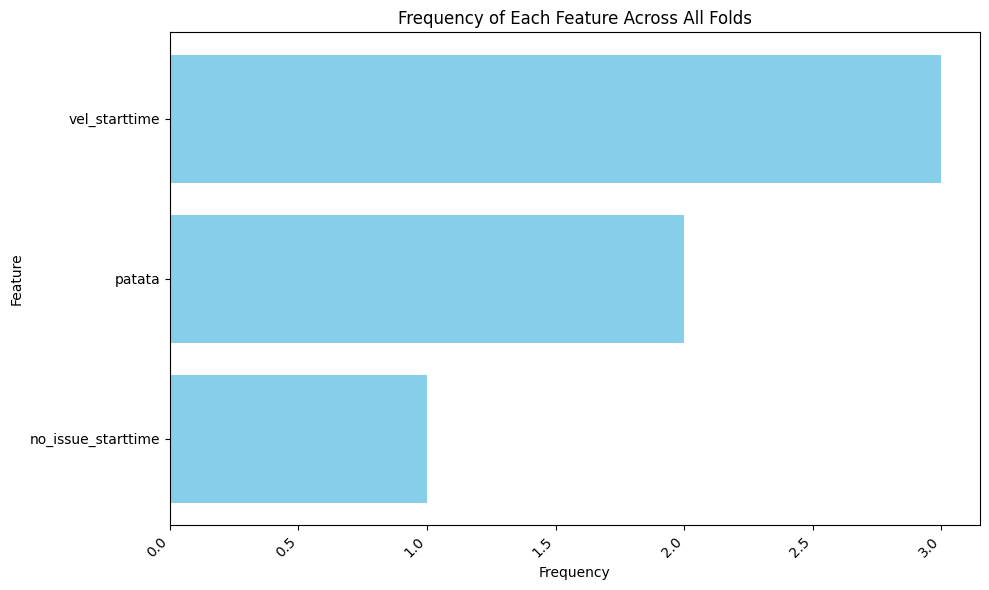

In [7]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Function to load JSON data from a file
def load_json(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

# Function to extract and count features
def count_features(data):
    feature_counts = defaultdict(int)
    
    for config in data:
        for fold in config['folds']:
            features = fold['features']
            
            for feature, count in features.items():
                feature_counts[feature] += count
    
    return feature_counts

# Function to plot feature counts
def plot_feature_counts(feature_counts):
    sorted_features = sorted(feature_counts.items(), key=lambda item: item[1], reverse=False)
    features = [item[0] for item in sorted_features]
    counts = [item[1] for item in sorted_features]
    
    plt.figure(figsize=(10, 6))
    plt.barh(features, counts, color='skyblue')
    plt.xlabel('Frequency')
    plt.ylabel('Feature')
    plt.title('Frequency of Each Feature Across All Folds')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# File path to the JSON file
file_path = 'outputs/test.json'

# Load the JSON data
data = load_json(file_path)

# Count the features
feature_counts = count_features(data)

# Plot the feature counts
plot_feature_counts(feature_counts)
